In [2]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

#### Get the flood dataset

In [3]:
# MERGED TWICE TO REMOVE DUPLICATES

flood_county = pd.read_csv(
    "../../02_processed_data/fema_flood_county_2000.csv"
).reset_index(drop=True)
flood_county.sort_values(by=["FIPS", "YEAR"]).dropna()
print(flood_county.info())
print(flood_county.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35450 entries, 0 to 35449
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FIPS                   35450 non-null  int64  
 1   YEAR                   35450 non-null  int64  
 2   STATE                  35450 non-null  object 
 3   CZ_NAME                35450 non-null  object 
 4   COUNT                  35450 non-null  int64  
 5   TOTAL_DAMAGE_PROPERTY  35450 non-null  float64
 6   TOTAL_DURATION_HOURS   35450 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.9+ MB
None
               FIPS          YEAR         COUNT  TOTAL_DAMAGE_PROPERTY  \
count  35450.000000  35450.000000  35450.000000           3.545000e+04   
mean   30434.366008   2010.019069     13.039126           3.367555e+06   
std    14880.622613      6.061159     18.316309           1.256051e+08   
min     1001.000000   2000.000000      1.000000           0.0

#### Get the HPI dataset

In [4]:
hpi_county = pd.read_csv("../../02_processed_data/hpi_county_2000.csv")
hpi_county.sort_values(by=["county_fips5", "yr"]).dropna()
print(hpi_county.info())
print(hpi_county.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21965 entries, 0 to 21964
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cbsa_code                 21965 non-null  int64  
 1   cbsa_title                21965 non-null  object 
 2   county_fips5              21965 non-null  int64  
 3   county/county_equivalent  21965 non-null  object 
 4   state_name                21965 non-null  object 
 5   place_name                21965 non-null  object 
 6   place_id                  21965 non-null  int64  
 7   yr                        21965 non-null  int64  
 8   index_nsa                 21965 non-null  float64
 9   index_prev                21965 non-null  float64
 10  hpi_change                21965 non-null  float64
 11  hpi_yoy                   21965 non-null  float64
dtypes: float64(4), int64(4), object(4)
memory usage: 2.0+ MB
None
          cbsa_code  county_fips5      place_id       

#### Checking for missing counties

In [5]:
# hpi_county[hpi_county["cbsa_code"] == "10100"]
flood_county[flood_county["FIPS"] == "46045"]

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS


In [6]:
min(hpi_county["county_fips5"]), max(hpi_county["county_fips5"])

(1001, 56025)

In [7]:
mask = ~hpi_county["county_fips5"].isin(flood_county["FIPS"])
hpi_no_flood = hpi_county.loc[mask, "county_fips5"].unique()
hpi_no_flood

array([ 2170, 41031,  9120,  9190,  2090,  9110,  9130, 15005,  9170,
        9180, 53059, 13173,  9140])

In [8]:
mask = ~flood_county["FIPS"].isin(hpi_county["county_fips5"])
flood_no_hpi = flood_county.loc[mask, "FIPS"].unique()
flood_no_hpi

array([ 1005,  1011,  1013, ..., 56041, 56043, 56045], shape=(2115,))

#### Merge flood and HPI datasets

In [9]:
hpi_flood = pd.merge(
    hpi_county[["county_fips5", "yr", "hpi_yoy", "index_nsa"]],
    flood_county,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "YEAR"],
    how="left",
)

# Identify columns that came from flood_county (excluding join keys)
flood_cols = [c for c in flood_county.columns if c not in ["FIPS", "YEAR"]]

# Impute those flood variables as 0
hpi_flood[flood_cols] = hpi_flood[flood_cols].fillna(0)

# Drop join-key duplicates from the merged df
hpi_flood = hpi_flood.drop(columns=["FIPS", "YEAR"])

hpi_flood.head()

,county_fips5,yr,hpi_yoy,index_nsa,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,48059,2000,1.226954,115.7100,0,0,0.0,0.0,0.00
1,48059,2001,4.070521,120.4200,0,0,0.0,0.0,0.00
2,48059,2002,2.850440,123.8525,TEXAS,CALLAHAN,2.0,807000.0,14.08
3,48059,2003,2.620052,127.0975,TEXAS,CALLAHAN,2.0,0.0,2.00
4,48059,2004,4.455241,132.7600,TEXAS,CALLAHAN,4.0,100000.0,4.18


In [10]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Get heat dataset

In [11]:
heat_county = pd.read_csv(
    "../../02_processed_data/county_heat_index_2000_2020_with_HSI.csv"
).reset_index(drop=True)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get the fIPS codes for states

In [12]:
us_states_fips = pd.read_csv("../../01_original_data/us_states_fips.csv").reset_index(
    drop=True
)
us_states_fips.head()

,state,fips,longname
0,AL,1,Alabama
1,AK,2,Alaska
2,AZ,4,Arizona
3,AR,5,Arkansas
4,CA,6,California


#### Create FIPS codes in heat dataset

In [13]:
def process_fips(heat_county):
    county_split = str(heat_county).split("-")
    state = str(
        us_states_fips[us_states_fips["state"] == county_split[0]]["fips"].values[0]
    ).zfill(2)
    county = county_split[1]
    return state + county


heat_county["FIPS"] = heat_county["id"].apply(lambda x: process_fips(x))
heat_county["FIPS"] = heat_county["FIPS"].astype(int)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI,FIPS
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615,1001
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779,1001
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973,1001
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611,1001
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037


In [14]:
# CHECKING FOR DUPLICATES
temp = (
    heat_county.value_counts(subset=["FIPS", "year"])
    .reset_index()
    .sort_values(by=["FIPS", "year"])
)
temp[temp["count"] > 1]

,FIPS,year,count


#### Merge heat and HPI/flood datasets

In [15]:
hpi_flood_heat = pd.merge(
    hpi_flood,
    heat_county[["FIPS", "year", "value", "heat_index", "HSI"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "year"],
    how="left",
)

# Identify columns that came from heat_county, excluding join keys
heat_cols = ["FIPS", "year", "value", "heat_index", "HSI"]

# Impute only heat-related variables as 0
hpi_flood_heat[heat_cols] = hpi_flood_heat[heat_cols].fillna(0)

# Drop join-key duplicates
hpi_flood_heat = hpi_flood_heat.drop(columns=["FIPS", "year"])

hpi_flood_heat.head()
hpi_flood_heat

,county_fips5,yr,hpi_yoy,index_nsa,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI
0,48059,2000,1.226954,115.7100,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057
1,48059,2001,4.070521,120.4200,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194
2,48059,2002,2.850440,123.8525,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792
3,48059,2003,2.620052,127.0975,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478
4,48059,2004,4.455241,132.7600,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233
...,...,...,...,...,...,...,...,...,...,...,...,...
21960,4027,2016,3.794342,171.2425,ARIZONA,YUMA,3.0,0.0,3.00,106.9,0.414770,0.872492
21961,4027,2017,3.854183,177.8425,0,0,0.0,0.0,0.00,107.2,0.419574,0.878639
21962,4027,2018,3.642268,184.3200,ARIZONA,YUMA,7.0,65000.0,17.83,106.4,0.402691,0.818690
21963,4027,2019,5.189345,193.8850,ARIZONA,YUMA,2.0,2000.0,7.87,106.7,0.410549,0.944888


In [16]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Merge the drought and wildfire datasets

In [17]:
drought_county = pd.read_csv(
    "../../02_processed_data/NCEI_annual_drought_county_FINAL.csv"
).reset_index(drop=True)
drought_county = drought_county[drought_county["FIPS"] != 0]
drought_county.sort_values(by=["FIPS", "Year"]).dropna()
drought_county = drought_county.drop(["County", "State", "State_abbr"], axis=1)

In [18]:
dupes = drought_county[drought_county.duplicated(subset=["FIPS", "Year"], keep=False)]
dupes = dupes.sort_values(by=["FIPS", "Year"])
drought_county = drought_county.drop_duplicates(subset=["FIPS", "Year"], keep="first")
drought_county.head()

,FIPS,Year,Annual_Mean_Index
0,1001,2000,-2.32
1,1001,2001,1.43
2,1001,2002,-0.76
3,1001,2003,2.39
4,1001,2004,0.00


In [19]:
drought_hpi_flood_heat = pd.merge(
    hpi_flood_heat,
    drought_county[["FIPS", "Year", "Annual_Mean_Index"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "Year"],
    how="left",
)

drought_hpi_flood_heat = drought_hpi_flood_heat.drop(columns=["FIPS", "Year"])

drought_hpi_flood_heat["Annual_Mean_Index"] = drought_hpi_flood_heat[
    "Annual_Mean_Index"
].fillna(0)

drought_hpi_flood_heat.head()

,county_fips5,yr,hpi_yoy,index_nsa,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index
0,48059,2000,1.226954,115.7100,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36
1,48059,2001,4.070521,120.4200,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39
2,48059,2002,2.850440,123.8525,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54
3,48059,2003,2.620052,127.0975,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96
4,48059,2004,4.455241,132.7600,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28


In [20]:
# CHECKING FOR DUPLICATES
temp = (
    drought_hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


In [21]:
wildfire_county = pd.read_csv(
    "../../02_processed_data/wildfire_data_preprocessed.csv"
).reset_index(drop=True)
wildfire_county.sort_values(by=["FIPS", "Year"]).dropna()
wildfire_county = wildfire_county.drop(["State"], axis=1)
wildfire_county.head()

,FIPS,Year,FIRE_FREQUENCY,TOTAL_FIRE_SIZE
0,1001,2003,43,274.8
1,1001,2004,86,744.5
2,1001,2005,63,234.2
3,1001,2006,62,534.7
4,1001,2007,93,477.3


In [22]:
wildfire_drought_hpi_flood_heat = pd.merge(
    drought_hpi_flood_heat,
    wildfire_county[["FIPS", "Year", "FIRE_FREQUENCY", "TOTAL_FIRE_SIZE"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "Year"],
    how="left",
)

wildfire_drought_hpi_flood_heat = wildfire_drought_hpi_flood_heat.drop(
    columns=["FIPS", "Year"]
)

wildfire_drought_hpi_flood_heat["FIRE_FREQUENCY"] = wildfire_drought_hpi_flood_heat[
    "FIRE_FREQUENCY"
].fillna(0)
wildfire_drought_hpi_flood_heat["TOTAL_FIRE_SIZE"] = wildfire_drought_hpi_flood_heat[
    "TOTAL_FIRE_SIZE"
].fillna(0)

wildfire_drought_hpi_flood_heat.head()

,county_fips5,yr,hpi_yoy,index_nsa,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE
0,48059,2000,1.226954,115.7100,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36,0.0,0.0
1,48059,2001,4.070521,120.4200,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39,0.0,0.0
2,48059,2002,2.850440,123.8525,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54,0.0,0.0
3,48059,2003,2.620052,127.0975,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96,1.0,100.0
4,48059,2004,4.455241,132.7600,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28,19.0,61.0


In [23]:
# CHECKING FOR DUPLICATES
temp = (
    wildfire_drought_hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Merge Drought/Wildfire/HPI/Flood/Heat/Hurricane datasets

In [24]:
storm_summary = pd.read_csv(
    "../../02_processed_data/storm_data_aggregated_county.csv", low_memory=False
)
storm_summary["year"] = storm_summary["year"].astype("int")
storm_summary["FIPS"] = storm_summary["FIPS"].astype("int")

huricane_grouped = storm_summary.groupby(["FIPS", "year"], as_index=False).agg(
    deaths_hurricane=("deaths", "sum"),
    injuries_hurricane=("injuries", "sum"),
    damage_hurricane=("damage", "sum"),
)

huricane_grouped.sort_values(by=["FIPS", "year"])

,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,1003,2002,0.0,0.0,75000
1,1003,2004,0.0,0.0,0
2,1003,2005,0.0,0.0,0
3,1003,2020,2.0,0.0,236080000
4,1013,2004,0.0,0.0,0
...,...,...,...,...,...
947,51730,2003,1.0,0.0,9700000
948,51740,2003,0.0,0.0,10000000
949,51800,2003,0.0,0.0,33000000
950,51810,2003,0.0,0.0,39400000


In [25]:
wildfire_drought_hpi_flood_heat_huricane = pd.merge(
    wildfire_drought_hpi_flood_heat,
    huricane_grouped,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "year"],
    how="left",
)

# Columns coming from huricane_grouped, excluding join keys
hurricane_cols = [c for c in huricane_grouped.columns if c not in ["FIPS", "year"]]

# Impute only hurricane variables as 0
wildfire_drought_hpi_flood_heat_huricane[hurricane_cols] = (
    wildfire_drought_hpi_flood_heat_huricane[hurricane_cols].fillna(0)
)


wildfire_drought_hpi_flood_heat_huricane

,county_fips5,yr,hpi_yoy,index_nsa,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,48059,2000,1.226954,115.7100,0,0,0.0,0.0,0.00,94.4,0.289948,0.509057,-3.36,0.0,0.00,NaN,NaN,0.0,0.0,0.0
1,48059,2001,4.070521,120.4200,0,0,0.0,0.0,0.00,95.7,0.353297,0.587194,0.39,0.0,0.00,NaN,NaN,0.0,0.0,0.0
2,48059,2002,2.850440,123.8525,TEXAS,CALLAHAN,2.0,807000.0,14.08,90.8,0.059089,0.323792,1.54,0.0,0.00,NaN,NaN,0.0,0.0,0.0
3,48059,2003,2.620052,127.0975,TEXAS,CALLAHAN,2.0,0.0,2.00,92.8,0.178862,0.442478,0.96,1.0,100.00,NaN,NaN,0.0,0.0,0.0
4,48059,2004,4.455241,132.7600,TEXAS,CALLAHAN,4.0,100000.0,4.18,89.6,-0.000561,0.413233,2.28,19.0,61.00,NaN,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21960,4027,2016,3.794342,171.2425,ARIZONA,YUMA,3.0,0.0,3.00,106.9,0.414770,0.872492,-2.68,11.0,1326.60,NaN,NaN,0.0,0.0,0.0
21961,4027,2017,3.854183,177.8425,0,0,0.0,0.0,0.00,107.2,0.419574,0.878639,-2.05,17.0,103.00,NaN,NaN,0.0,0.0,0.0
21962,4027,2018,3.642268,184.3200,ARIZONA,YUMA,7.0,65000.0,17.83,106.4,0.402691,0.818690,-2.95,191.0,594.87,NaN,NaN,0.0,0.0,0.0
21963,4027,2019,5.189345,193.8850,ARIZONA,YUMA,2.0,2000.0,7.87,106.7,0.410549,0.944888,-0.23,64.0,1265.91,NaN,NaN,0.0,0.0,0.0


In [31]:
df = wildfire_drought_hpi_flood_heat_huricane

# columns to drop
cols_to_drop = [
    "YEAR",
    "year_y",
    "State_fire",
    "State_ncei",
    "State_abbr",
    "Year",
    "county_fips5",
    "year_x",
    "FIPS",
    "year",
]

# drop them from df (ignore any that might be missing)
df = df.drop(columns=cols_to_drop, errors="ignore")

# quick check
print(df.columns)
print(df.info())
print(df.describe())

Index(['yr', 'hpi_yoy', 'index_nsa', 'STATE', 'CZ_NAME', 'COUNT',
       'TOTAL_DAMAGE_PROPERTY', 'TOTAL_DURATION_HOURS', 'value', 'heat_index',
       'HSI', 'Annual_Mean_Index', 'FIRE_FREQUENCY', 'TOTAL_FIRE_SIZE',
       'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21965 entries, 0 to 21964
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     21965 non-null  int64  
 1   hpi_yoy                21965 non-null  float64
 2   index_nsa              21965 non-null  float64
 3   STATE                  21965 non-null  object 
 4   CZ_NAME                21965 non-null  object 
 5   COUNT                  21965 non-null  float64
 6   TOTAL_DAMAGE_PROPERTY  21965 non-null  float64
 7   TOTAL_DURATION_HOURS   21965 non-null  float64
 8   value                  21965 non-null  float64
 9   heat_

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

In [29]:
df = df.rename(
    columns={
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        # "HSI": "HEAT_HSI",
        "index_nsa": "hpi",
    }
)
df.columns

Index(['yr', 'hpi_yoy', 'hpi', 'STATE', 'CZ_NAME', 'FLOOD_FREQUENCY',
       'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_VALUE',
       'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY',
       'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane',
       'damage_hurricane'],
      dtype='object')

## OLS Regression

Index(['county_fips', 'yr', 'hpi_yoy', 'hpi', 'STATE', 'CZ_NAME',
       'FLOOD_FREQUENCY', 'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS',
       'HEAT_VALUE', 'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX',
       'FIRE_FREQUENCY', 'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane',
       'damage_hurricane'],
      dtype='object')

Numeric predictors used:
['county_fips', 'yr', 'hpi', 'FLOOD_FREQUENCY', 'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_VALUE', 'HEAT_INDEX', 'HSI', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY', 'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane']

=== OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:                hpi_yoy   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     116.8
Date:                Tue, 09 Dec 2025   P

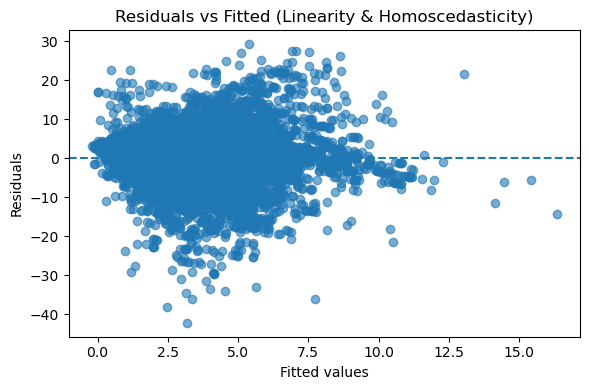

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/graphics/regressionplots.py:744: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/d6/ctkwr8y15b3fjbrsjdbc2zt80000gn/T/ipykernel_44906/2472246094.py:106: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


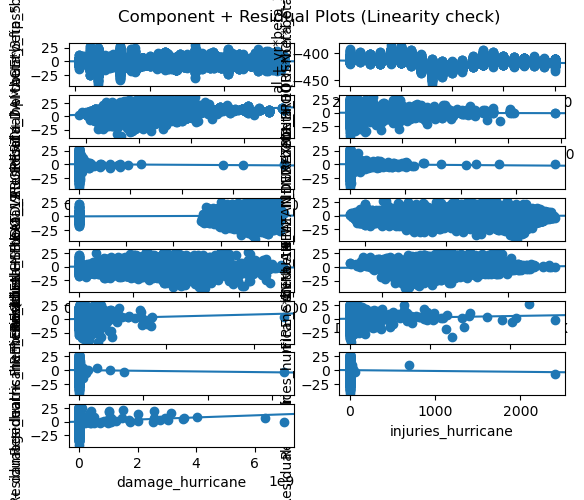


Durbin–Watson statistic: 0.487


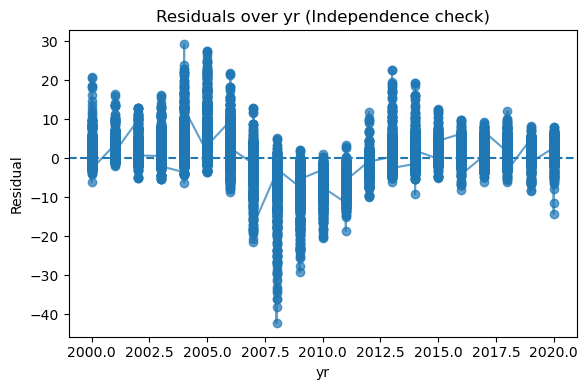

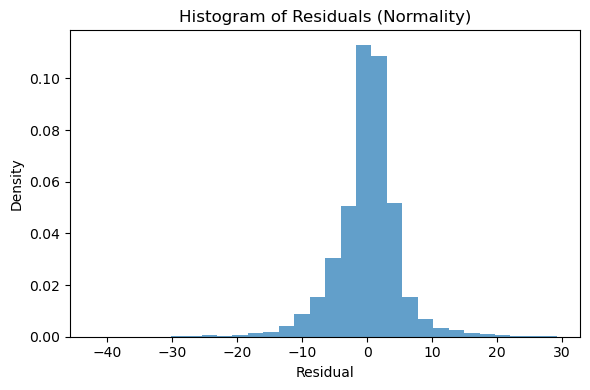

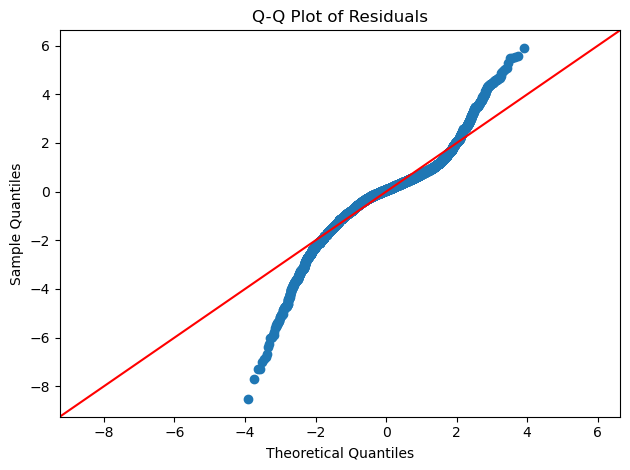


Shapiro–Wilk: stat=0.927, p=5.34e-72
Jarque–Bera: stat=25696.569, p=0, skew=-0.466, kurtosis=8.216


/opt/miniconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 21965.
  res = hypotest_fun_out(*samples, **kwds)


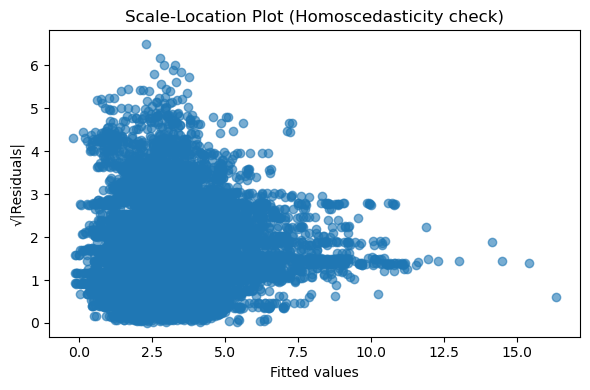

X_exog shape for BP: (21965, 16)

Breusch–Pagan test: LM stat=417.078, p=1.77e-79, F=28.323, F p=2.78e-80


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tools.tools import fullrank
from scipy import stats

# -------------------------------------------
# 0. Start from your merged dataframe
# -------------------------------------------
df = wildfire_drought_hpi_flood_heat_huricane

# columns to drop (join keys / IDs / duplicates)
cols_to_drop = [
    "YEAR",
    "year_y",
    "State_fire",
    "State_ncei",
    "State_abbr",
    "Year",
    "year_x",
    "FIPS",
    "year",
]
df = df.drop(columns=cols_to_drop, errors="ignore")

# rename for cleaner names
df = df.rename(
    columns={
        "HPI_YoY": "hpi_yoy",
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        "index_nsa": "hpi",
        "county_fips5": "county_fips",
    }
)

print(df.columns)

## SAVE FILE FOR NN MODELING FOR CONSISTENT DATA - but I added FIPS
df.to_csv(
    "../../02_processed_data/wildfire_drought_hpi_flood_heat_huricane.csv", index=False
)

# -------------------------------------------
# 1. Build X and y
# -------------------------------------------
target = "hpi_yoy"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = [target]  # response only; FIPS is already dropped

predictors = [c for c in numeric_cols if c not in exclude_cols]
print("\nNumeric predictors used:")
print(predictors)

X = df[predictors].copy()
y = df[target]

# Drop any constant or duplicate columns just to be safe
constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    X = X.drop(columns=constant_cols)

dup_mask = X.T.duplicated()
if dup_mask.any():
    print("Dropping duplicate columns:", list(X.columns[dup_mask]))
    X = X.loc[:, ~dup_mask]

# Add intercept
X = sm.add_constant(X)

# -------------------------------------------
# 2. Fit OLS
# -------------------------------------------
model = sm.OLS(y, X, missing="drop").fit()
print("\n=== OLS Summary ===")
print(model.summary())

resid = model.resid
fitted = model.fittedvalues

# -------------------------------------------
# 3. L – Linearity
# -------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Linearity & Homoscedasticity)")
plt.tight_layout()
plt.show()

fig = sm.graphics.plot_ccpr_grid(model)
fig.suptitle("Component + Residual Plots (Linearity check)", y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------------------
# 4. I – Independence
# -------------------------------------------
dw = durbin_watson(resid)
print(f"\nDurbin–Watson statistic: {dw:.3f}")

# If 'yr' is still in df, use it as time variable
if "yr" in df.columns:
    temp = pd.DataFrame({"yr": df["yr"], "resid": resid}).dropna()
    temp = temp.sort_values(by="yr")
    plt.figure(figsize=(6, 4))
    plt.plot(temp["yr"], temp["resid"], marker="o", linestyle="-", alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("yr")
    plt.ylabel("Residual")
    plt.title("Residuals over yr (Independence check)")
    plt.tight_layout()
    plt.show()

# -------------------------------------------
# 5. N – Normality
# -------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(resid, bins=30, density=True, alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Histogram of Residuals (Normality)")
plt.tight_layout()
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"\nShapiro–Wilk: stat={shapiro_stat:.3f}, p={shapiro_p:.3g}")

jb_stat, jb_p, skew, kurt = sm.stats.jarque_bera(resid)
print(
    f"Jarque–Bera: stat={jb_stat:.3f}, p={jb_p:.3g}, skew={skew:.3f}, kurtosis={kurt:.3f}"
)

from statsmodels.tools.tools import fullrank

# ---------------------------------------------------
# 7. E – Equal variance (Scale-location + Breusch–Pagan)
# ---------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location Plot (Homoscedasticity check)")
plt.tight_layout()
plt.show()

X_exog = model.model.exog
print("X_exog shape for BP:", X_exog.shape)

# Only run BP if we have constant + at least 1 predictor
if X_exog.shape[1] < 2:
    print(
        "\nNot enough predictors to run Breusch–Pagan test (need constant + at least 1 covariate)."
    )
else:
    bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(resid, X_exog)
    print(
        f"\nBreusch–Pagan test: LM stat={bp_stat:.3f}, p={bp_p:.3g}, "
        f"F={bp_f:.3f}, F p={bp_f_p:.3g}"
    )

## Ridge Regression

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

X_ridge = df[predictors].copy()
y_ridge = df[target].copy()

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv = make_pipeline(
    StandardScaler(), RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
)

ridge_cv.fit(X_ridge, y_ridge)

ridge_step = ridge_cv.named_steps["ridgecv"]
print("Chosen alpha:", ridge_step.alpha_)

y_pred_ridge = ridge_cv.predict(X_ridge)
print("Ridge MSE:", mean_squared_error(y_ridge, y_pred_ridge))
print("Ridge R^2:", r2_score(y_ridge, y_pred_ridge))

# Coefficients on standardized scale:
for name, coef in zip(predictors, ridge_step.coef_):
    print(f"{name:30s} {coef: .4f}")

Chosen alpha: 100.0
Ridge MSE: 25.97063595602957
Ridge R^2: 0.015388868518623533
yr                             -0.4543
FLOOD_FREQUENCY                -0.1004
FLOOD_PROPERTY_DAMAGE           0.0057
FLOOD_DURATION_HOURS           -0.0807
HEAT_VALUE                     -0.0114
HEAT_INDEX                      0.1697
HSI                            -0.1346
DROUGHT_ANNUAL_MEAN_INDEX       0.3636
FIRE_FREQUENCY                  0.2777
FIRE_SIZE                       0.2471
deaths_hurricane               -0.0196
injuries_hurricane             -0.0242
damage_hurricane                0.2102


## ar(1)

     yr   hpi_yoy
0  2000  1.226954
1  2001  4.070521
2  2002  2.850440
3  2003  2.620052
4  2004  4.455241
yr
2000    4.509167
2001    5.881094
2002    4.767851
2003    5.167268
2004    7.155412
Name: hpi_yoy, dtype: float64


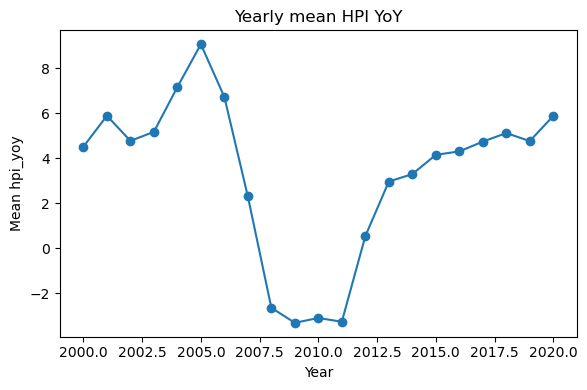

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# starting from your cleaned df
# it must have columns: 'yr' and 'hpi_yoy'
print(df[["yr", "hpi_yoy"]].head())

# 1) aggregate to yearly mean HPI YoY across counties
hpi_yearly = df.groupby("yr", as_index=True)["hpi_yoy"].mean().sort_index()

print(hpi_yearly.head())

# quick plot
plt.figure(figsize=(6, 4))
hpi_yearly.plot(marker="o")
plt.title("Yearly mean HPI YoY")
plt.xlabel("Year")
plt.ylabel("Mean hpi_yoy")
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# AR(1) ≡ ARIMA(p=1, d=0, q=0)
ar1_model = ARIMA(hpi_yearly, order=(1, 0, 0)).fit()

print(ar1_model.summary())

                               SARIMAX Results                                
Dep. Variable:                hpi_yoy   No. Observations:                   21
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -44.113
Date:                Tue, 18 Nov 2025   AIC                             94.225
Time:                        17:20:41   BIC                             97.359
Sample:                             0   HQIC                            94.905
                                 - 21                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8489      2.998      1.284      0.199      -2.028       9.725
ar.L1          0.8153      0.118      6.887      0.000       0.583       1.047
sigma2         3.7109      1.237      2.999      0.0

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


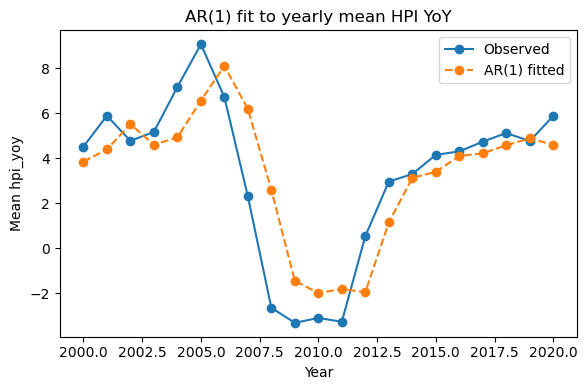

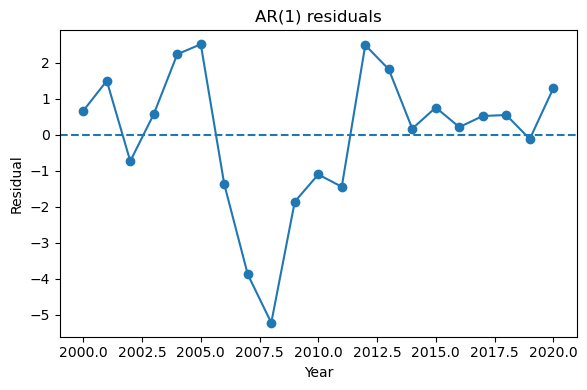

In [ ]:
# Fitted values (in-sample)
fitted_ar1 = ar1_model.fittedvalues

plt.figure(figsize=(6, 4))
plt.plot(hpi_yearly.index, hpi_yearly, marker="o", label="Observed")
plt.plot(hpi_yearly.index, fitted_ar1, marker="o", linestyle="--", label="AR(1) fitted")
plt.xlabel("Year")
plt.ylabel("Mean hpi_yoy")
plt.title("AR(1) fit to yearly mean HPI YoY")
plt.legend()
plt.tight_layout()
plt.show()

# Residuals
resid_ar1 = ar1_model.resid

plt.figure(figsize=(6, 4))
plt.plot(hpi_yearly.index, resid_ar1, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.title("AR(1) residuals")
plt.tight_layout()
plt.show()

#### We aggregated county-level HPI growth to yearly means and fit an AR(1) model, $Y_t = c + \phi_1 Y_{t-1} + \varepsilon_t$. The estimated AR coefficient $\hat{\phi}_1 = 0.82$ ($p < 0.001$) indicates strong persistence in annual HPI growth: high-growth years tend to be followed by high growth in the next year. The model captures the broad rise, crash around 2008--2011, and subsequent recovery, but residuals remain large during the crash period, reflecting shocks that are not well captured by a simple AR(1) structure.


## add other predictors on AR(1) model

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# columns to use as exogenous predictors (everything except yr and hpi_yoy)
exog_vars = [
    "FLOOD_FREQUENCY",
    "FLOOD_PROPERTY_DAMAGE",
    "FLOOD_DURATION_HOURS",
    "HEAT_VALUE",
    "HEAT_INDEX",
    "HSI",
    "DROUGHT_ANNUAL_MEAN_INDEX",
    "FIRE_FREQUENCY",
    "FIRE_SIZE",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane",
]

# 1) Aggregate to yearly means (you could choose sum for counts if you prefer)
yearly = df.groupby("yr")[["hpi_yoy"] + exog_vars].mean().sort_index()

print(yearly.head())

y_ts = yearly["hpi_yoy"]
X_ts = yearly[exog_vars]

       hpi_yoy  FLOOD_FREQUENCY  FLOOD_PROPERTY_DAMAGE  FLOOD_DURATION_HOURS  \
yr                                                                             
2000  4.509167         5.241148           3.850429e+05             18.984278   
2001  5.881094         7.012428           4.612108e+05             73.500239   
2002  4.767851         8.296367           1.207863e+05             52.033308   
2003  5.167268        11.851816           1.827840e+06             49.933098   
2004  7.155412        12.843212           7.884085e+05             54.662314   

      HEAT_VALUE  HEAT_INDEX       HSI  DROUGHT_ANNUAL_MEAN_INDEX  \
yr                                                                  
2000   84.173684    0.181544  0.303944                  -1.039809   
2001   84.354207    0.186816  0.303105                  -0.443786   
2002   85.712428    0.289384  0.315101                  -0.639665   
2003   83.829063    0.141872  0.278998                   0.756616   
2004   82.107075    0.057

In [49]:
# AR(1) with exogenous regressors
ar1_x_model = ARIMA(endog=y_ts, exog=X_ts, order=(1, 0, 0)).fit()

print(ar1_x_model.summary())

                               SARIMAX Results                                
Dep. Variable:                hpi_yoy   No. Observations:                   21
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -38.088
Date:                Tue, 18 Nov 2025   AIC                            106.177
Time:                        21:23:54   BIC                            121.845
Sample:                             0   HQIC                           109.577
                                 - 21                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                      1033.4826      0.038   2.73e+04      0.000    1033.408    1033.557
FLOOD_FREQUENCY              -0.6547      0.409     -1.600      0.110      -1.457     

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


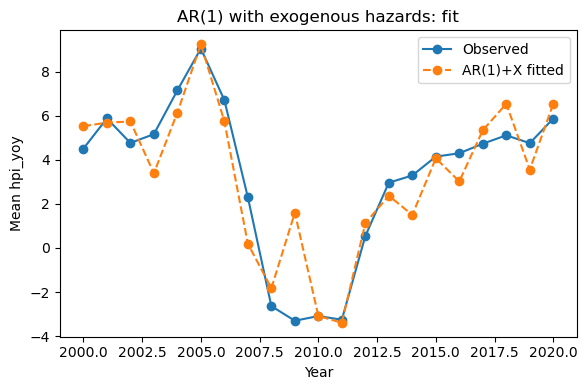

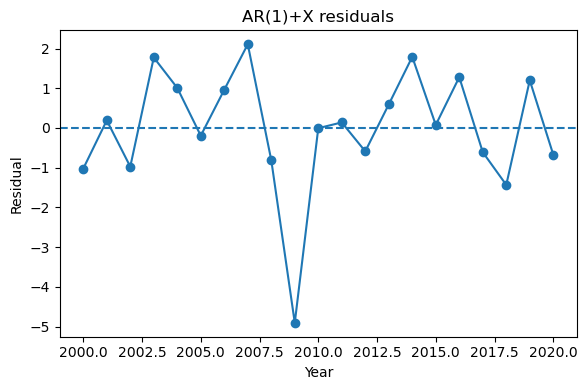

In [ ]:
# In-sample fitted values
fitted_ar1x = ar1_x_model.fittedvalues

plt.figure(figsize=(6, 4))
plt.plot(y_ts.index, y_ts, marker="o", label="Observed")
plt.plot(y_ts.index, fitted_ar1x, marker="o", linestyle="--", label="AR(1)+X fitted")
plt.xlabel("Year")
plt.ylabel("Mean hpi_yoy")
plt.title("AR(1) with exogenous hazards: fit")
plt.legend()
plt.tight_layout()
plt.show()

# Residuals
resid_ar1x = ar1_x_model.resid

plt.figure(figsize=(6, 4))
plt.plot(y_ts.index, resid_ar1x, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.title("AR(1)+X residuals")
plt.tight_layout()
plt.show()

#### We extended the AR(1) model for yearly mean HPI growth to include exogenous measures of flood, heat, drought, fire, and hurricane hazards (ARIMAX(1,0,0)). While the exogenous terms largely removed the residual autocorrelation (Ljung–Box p = 0.83 and an insignificant AR(1) coefficient), the model is heavily over-parameterized for a 21-year series, leading to an ill-conditioned covariance matrix and unstable, difficult-to-interpret coefficient estimates. In practice, a more parsimonious specification with a small number of hazard indices (or regularization) would be preferable.

## PCA

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ts)
ar1_x_model = ARIMA(endog=y_ts, exog=X_scaled, order=(1, 0, 0)).fit()

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [38]:
print(ar1_x_model.summary())

                               SARIMAX Results                                
Dep. Variable:                hpi_yoy   No. Observations:                   21
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -35.807
Date:                Tue, 18 Nov 2025   AIC                            101.613
Time:                        17:20:42   BIC                            117.281
Sample:                             0   HQIC                           105.013
                                 - 21                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.2954      2.804      1.175      0.240      -2.201       8.792
x1            -1.3878      2.359     -0.588      0.556      -6.012       3.236
x2             0.0759      1.207      0.063      0.9

## EDA on merged dataset

In [39]:
for_training = wildfire_drought_hpi_flood_heat[
    [
        # "FIPS",
        "hpi_yoy",
        # "YEAR",
        "COUNT",
        "TOTAL_DAMAGE_PROPERTY",
        "TOTAL_DURATION_HOURS",
        "value",  # heat
        "heat_index",
        # "HSI",
        "Annual_Mean_Index",  # drought
        "FIRE_FREQUENCY",
        "TOTAL_FIRE_SIZE",
    ]
]
for_training = for_training.rename(
    columns={
        "hpi_yoy": "HPI_YoY",
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        # "HSI": "HEAT_HSI",
    }
)

In [40]:
import numpy as np

for_training["LOG_FLOOD_DAMAGE"] = np.log1p(for_training["FLOOD_PROPERTY_DAMAGE"])
for_training["LOG_FIRE_SIZE"] = np.log1p(for_training["FIRE_SIZE"])
for_training["LOG_FIRE_FREQUENCY"] = np.log1p(for_training["FIRE_FREQUENCY"])
for_training["LOG_FLOOD_DURATION_HOURS"] = np.log1p(
    for_training["FLOOD_DURATION_HOURS"]
)
for_training["LOG_FLOOD_FREQUENCY"] = np.log1p(for_training["FLOOD_FREQUENCY"])

for_training = for_training.drop(
    columns=[
        "FLOOD_PROPERTY_DAMAGE",
        "FIRE_SIZE",
        "FIRE_FREQUENCY",
        "FLOOD_FREQUENCY",
        "FLOOD_DURATION_HOURS",
    ]
)

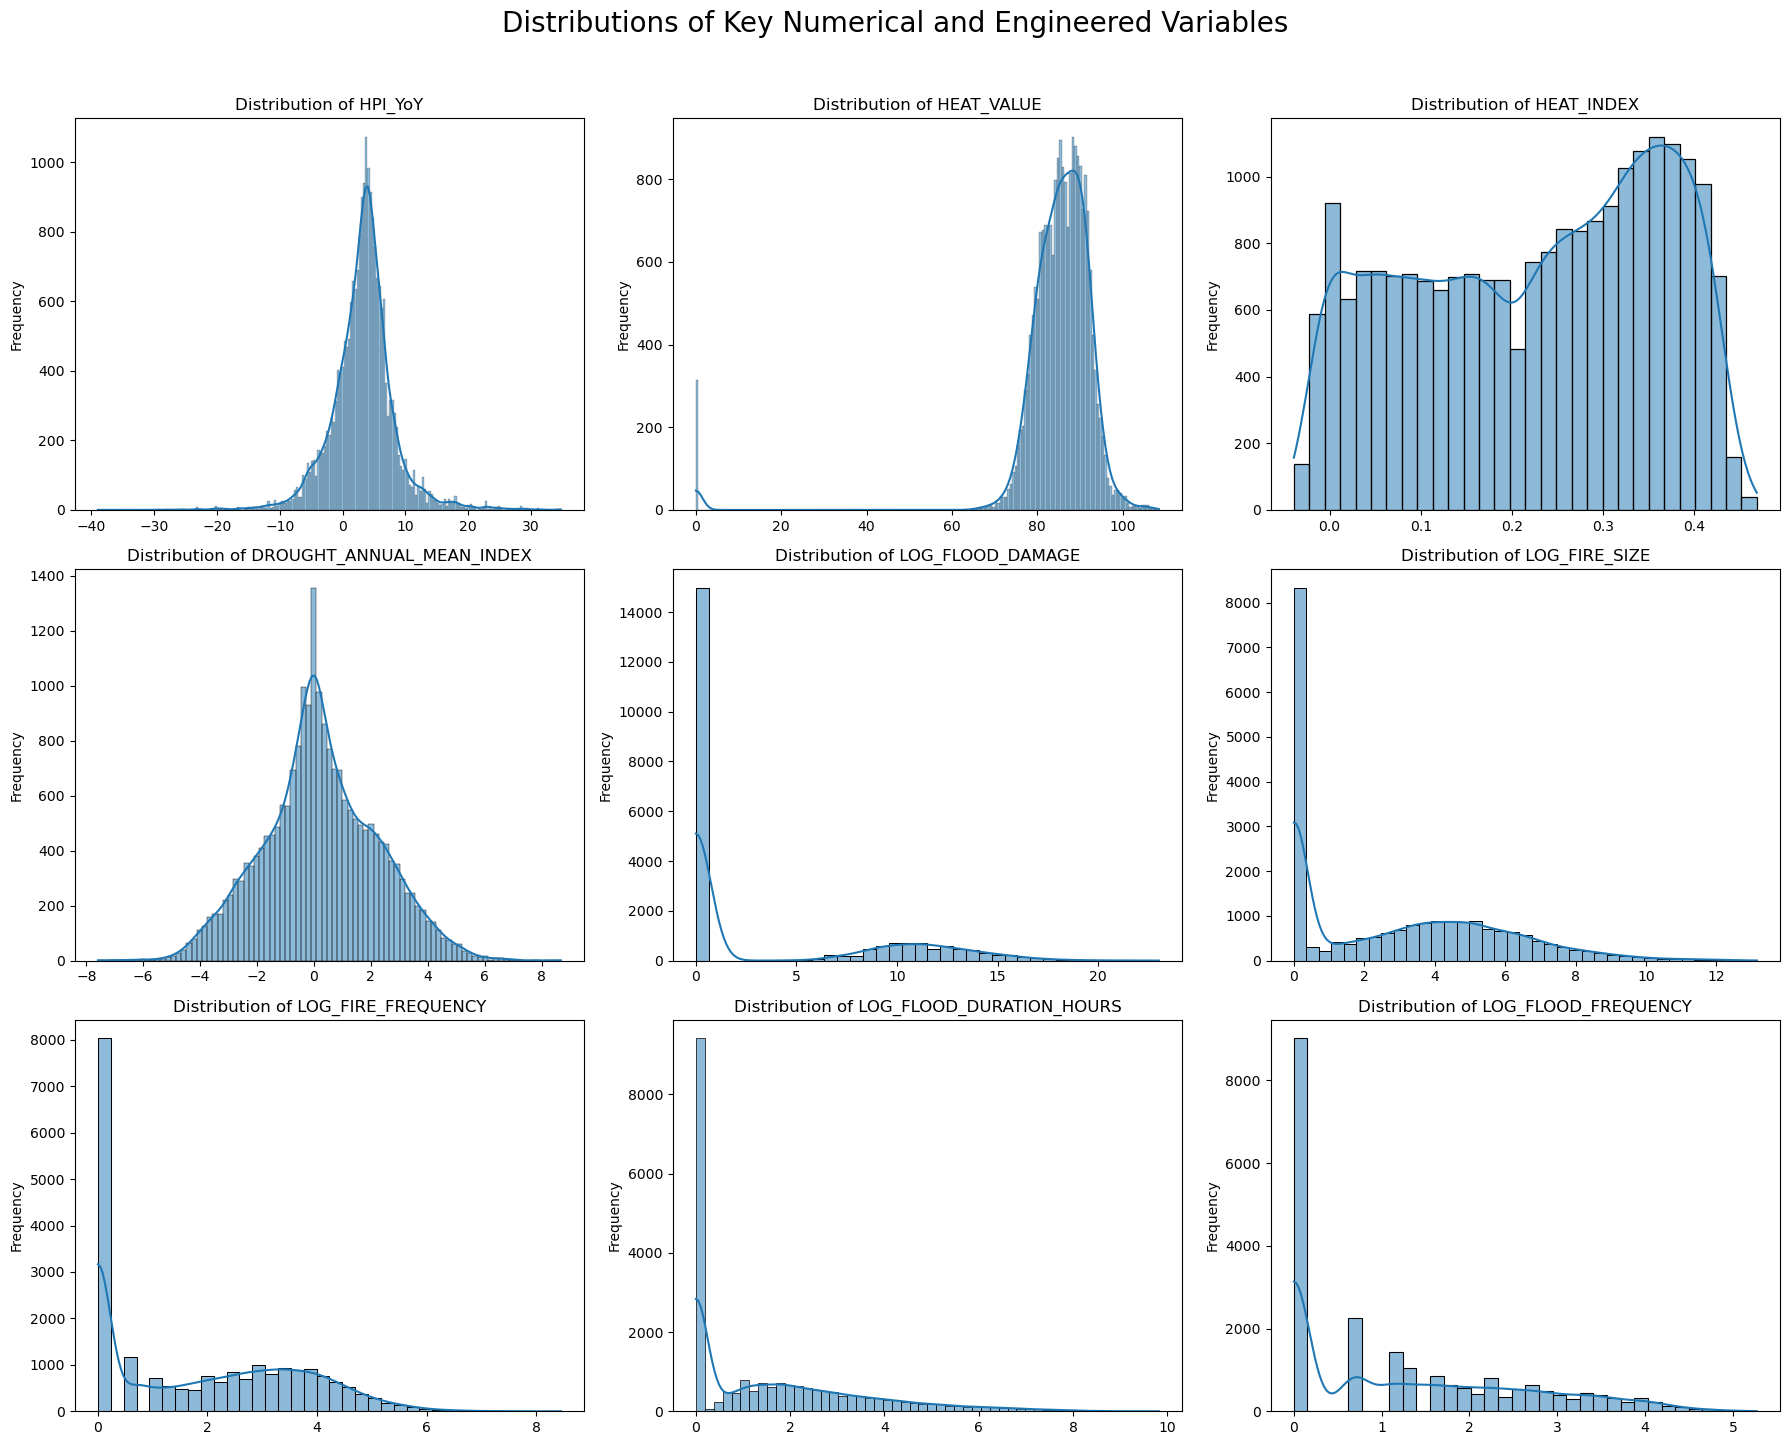

In [41]:
# Create a figure with a 3x3 grid of subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))

# The .flatten() function turns the 3x3 grid into a simple list to loop over
for col, ax in zip(for_training, axes.flatten()):
    sns.histplot(data=for_training, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel("")  # Remove individual x-labels for a cleaner look
    ax.set_ylabel("Frequency")

# Add a main title to the entire figure
fig.suptitle(
    "Distributions of Key Numerical and Engineered Variables", fontsize=20, y=0.99
)

# Automatically adjust subplot spacing to prevent labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

In [42]:
# max(for_training["FLOOD_PROPERTY_DAMAGE"]), for_training[
#     "FLOOD_PROPERTY_DAMAGE"
# ].median()
# for_training = for_training.drop(
#     for_training[for_training["FLOOD_PROPERTY_DAMAGE"] > 1000051100].index
# )

In [43]:
# Split data into features and target
y = for_training["HPI_YoY"]
X = for_training.drop(columns=["HPI_YoY"])  # ,"FIPS","YEAR"

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train_not_scaled, X_test_not_scaled, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
# # Fit scaler only on the training set
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train_not_scaled)

# # Apply the same transformation to the test set
# X_test = scaler.transform(X_test_not_scaled)

#### Checking for multicollinearity

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [
    variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])
]
print(vif)

                     feature        VIF
0                      const  56.206329
1                 HEAT_VALUE   1.140488
2                 HEAT_INDEX   1.378412
3  DROUGHT_ANNUAL_MEAN_INDEX   1.447798
4           LOG_FLOOD_DAMAGE   1.550411
5              LOG_FIRE_SIZE   3.764859
6         LOG_FIRE_FREQUENCY   3.703936
7   LOG_FLOOD_DURATION_HOURS   2.269740
8        LOG_FLOOD_FREQUENCY   2.020065


In [47]:
corr = X.corr().abs()
high_corr = corr[corr > 0.8]
print(high_corr)

                           HEAT_VALUE  HEAT_INDEX  DROUGHT_ANNUAL_MEAN_INDEX  \
HEAT_VALUE                        1.0         NaN                        NaN   
HEAT_INDEX                        NaN         1.0                        NaN   
DROUGHT_ANNUAL_MEAN_INDEX         NaN         NaN                        1.0   
LOG_FLOOD_DAMAGE                  NaN         NaN                        NaN   
LOG_FIRE_SIZE                     NaN         NaN                        NaN   
LOG_FIRE_FREQUENCY                NaN         NaN                        NaN   
LOG_FLOOD_DURATION_HOURS          NaN         NaN                        NaN   
LOG_FLOOD_FREQUENCY               NaN         NaN                        NaN   

                           LOG_FLOOD_DAMAGE  LOG_FIRE_SIZE  \
HEAT_VALUE                              NaN            NaN   
HEAT_INDEX                              NaN            NaN   
DROUGHT_ANNUAL_MEAN_INDEX               NaN            NaN   
LOG_FLOOD_DAMAGE               

In [48]:
# Add a constant (intercept) for statsmodels
X_const = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X_const).fit()

# Print summary
print(model.summary())

# Optionally evaluate with train/test split
model_split = sm.OLS(y_train, X_train).fit()
y_pred = model_split.predict(X_test)

print("\nR² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

                            OLS Regression Results                            
Dep. Variable:                HPI_YoY   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     22.26
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           3.71e-34
Time:                        17:20:43   Log-Likelihood:                -67018.
No. Observations:               21965   AIC:                         1.341e+05
Df Residuals:                   21956   BIC:                         1.341e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

NameError: name 'X_train' is not defined

In [ ]:
w = 1 / (model.resid**2)
wls_model = sm.WLS(y, X_const, weights=w).fit()
print(wls_model.summary())

In [ ]:
# Add constant
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# ---- STEP 1: Fit an initial OLS to get residuals ----
ols_model = sm.OLS(y_train, X_train_const).fit()

# Compute weights = 1 / residual² (classic heteroscedastic correction)
weights = 1 / (ols_model.resid**2)
weights.replace([np.inf, -np.inf], np.nan, inplace=True)
weights.fillna(weights.median(), inplace=True)

# ---- STEP 2: Fit Weighted Least Squares (WLS) using training weights ----
wls_model = sm.WLS(y_train, X_train_const, weights=weights).fit()

print(wls_model.summary())

# ---- STEP 3: Evaluate on test data ----
y_pred = wls_model.predict(X_test_const)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"\nTest R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Ridge Regression
ridge = Pipeline(
    [("scaler", StandardScaler()), ("model", RidgeCV(alphas=[0.1, 1, 10], cv=5))]
)
ridge.fit(X_train, y_train)

print("R² (ridge):", ridge.score(X_test, y_test))

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(model.fittedvalues, model.resid, alpha=0.5)
plt.axhline(0, color="r")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(
    corr,
    # .drop(
    #     columns=["State FIPS Code", "County FIPS Code", "State-County FIPS Code"]
    # ).iloc[3:22, 3:22],
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".1f",
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
print("R² (RF):", rf.score(X_test, y_test))

In [ ]:
rf.feature_importances_

## Autoregression Modeling 

In [ ]:
for_AR = wildfire_drought_hpi_flood_heat[
    [
        # "FIPS",
        "hpi_yoy",
        "YEAR",
        "COUNT",
        "TOTAL_DAMAGE_PROPERTY",
        "TOTAL_DURATION_HOURS",
        "value",  # heat
        "heat_index",
        "HSI",
        "Annual_Mean_Index",  # drought
        "FIRE_FREQUENCY",
        "TOTAL_FIRE_SIZE",
    ]
]
for_AR = for_AR.rename(
    columns={
        "hpi_yoy": "HPI_YoY",
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "value": "HEAT_VALUE",
        "heat_index": "HEAT_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
        "HSI": "HEAT_HSI",
    }
)

NameError: name 'wildfire_drought_hpi_flood_heat' is not defined

In [ ]:
for_AR

In [ ]:
# can you do with Heteroscedasticity Correction?
import pandas as pd
import statsmodels.api as sm

# Keep 5 years of data
# subset = for_AR[for_AR['YEAR'].between(2016, 2020)]

# Define time series
y = for_AR["HPI_YoY"].astype(float)

# Fit AR(1)
model = sm.tsa.ARIMA(y, order=(1, 0, 0))  # AR(1)
results = model.fit()

print(results.summary())

# Forecast 5 steps ahead (next 5 years)
forecast = results.forecast(steps=10)
print("Forecast for next 5 years:")
print(forecast)

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model

# === Step 1: Prepare your time series ===
# Assuming `flood` has ['YEAR', 'HPI_YoY'] columns
flood = for_AR.sort_values("YEAR")
y = flood["HPI_YoY"].dropna().astype(float)

# === Step 2: Fit AR(1) model ===
ar1_model = sm.tsa.ARIMA(y, order=(1, 0, 0))
ar1_results = ar1_model.fit()
print("\n=== AR(1) Summary ===")
print(ar1_results.summary())

# === Step 3: Test for heteroscedasticity (ARCH test) ===
# Null hypothesis: no ARCH effects (homoscedastic)
arch_test = het_arch(ar1_results.resid)
print("\nARCH test p-value:", arch_test[1])

if arch_test[1] < 0.05:
    print(
        "⚠️ Significant heteroscedasticity detected — switching to AR(1)-GARCH(1,1)..."
    )

    # === Step 4: Fit AR(1)-GARCH(1,1) ===
    garch_model = arch_model(y, mean="AR", lags=1, vol="GARCH", p=1, q=1)
    garch_results = garch_model.fit(disp="off")

    print("\n=== AR(1)-GARCH(1,1) Summary ===")
    print(garch_results.summary())

    # === Step 5: Forecast 5 steps ahead ===
    forecast = garch_results.forecast(horizon=5)
    print("\nForecasted mean values (next 5 years):")
    print(forecast.mean.tail(1))
else:
    print("✅ No significant heteroscedasticity — keeping AR(1) model.")

    # === Step 5: Forecast 5 steps ahead ===
    forecast = ar1_results.forecast(steps=5)
    print("\nForecasted mean values (next 5 years):")
    print(forecast)